## Classifier Model: Logistic Regression

In [11]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parents[1]))
from src.utils import plot_roc_curve, conf_matrix

In [12]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import pandas as pd
import numpy as np

df = pd.read_csv('../../data/processed/creditcard-processed.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Model Creation

In [13]:
X_feats = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
xtrain, xtest, ytrain, ytest = train_test_split(
    X_feats, y, random_state=42, stratify=y
)

xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

_lr = LogisticRegression()
_lr.fit(xtrain_scaled, ytrain)

yhat_lr = _lr.predict(xtest_scaled)
yhat_prob = _lr.predict_proba(xtest_scaled)[:,1]
threshold = (yhat_prob >= 0.80).astype(int)

test_score = _lr.score(xtest_scaled, ytest)
train_score = _lr.score(xtrain_scaled, ytrain)

print(f"Test Score: {test_score:.3f}")
print(f"Train Score: {train_score:.3f}")

Test Score: 0.999
Train Score: 0.999


## ROC Curve

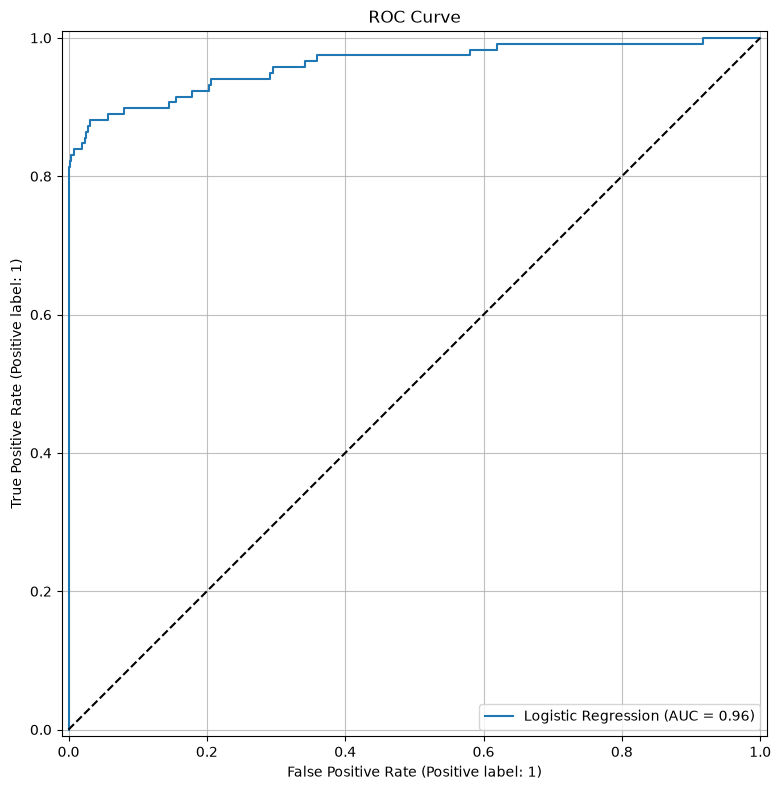

In [14]:
plot_roc_curve(_lr, xtest_scaled, ytest, 'Logistic Regression')

## Confusion Matrices (with and without 80% threshold)

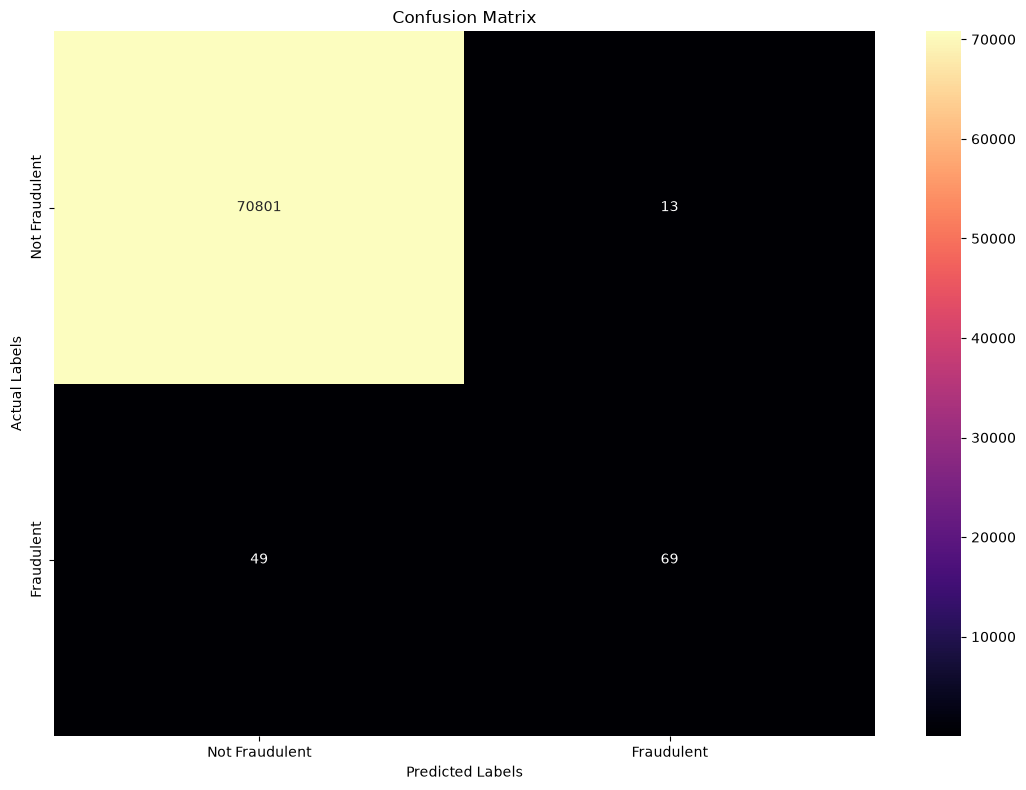

In [15]:
conf_matrix(ytest, yhat_lr, ['Not Fraudulent', 'Fraudulent'])

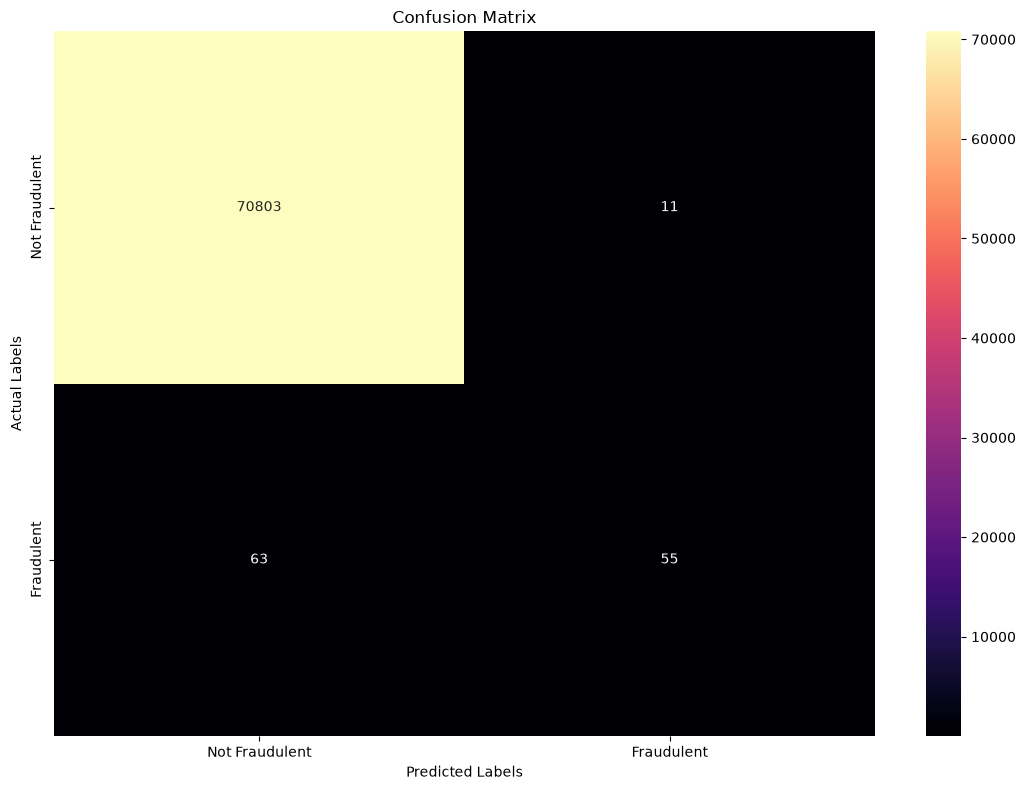

In [16]:
conf_matrix(ytest, threshold, ['Not Fraudulent', 'Fraudulent'])

## Classification Reports

In [17]:
print(classification_report(ytest, yhat_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.84      0.58      0.69       118

    accuracy                           1.00     70932
   macro avg       0.92      0.79      0.84     70932
weighted avg       1.00      1.00      1.00     70932



In [18]:
print(classification_report(ytest, threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.83      0.47      0.60       118

    accuracy                           1.00     70932
   macro avg       0.92      0.73      0.80     70932
weighted avg       1.00      1.00      1.00     70932



## Dataset Sampling

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

xtrain_sampled, ytrain_sampled = smote.fit_resample(xtrain, ytrain)

xtrain_sampled_scaled = scaler.fit_transform(xtrain_sampled)
xtest_scaled = scaler.transform(xtest)

lr = LogisticRegression()

lr.fit(xtrain_sampled_scaled, ytrain_sampled)
lr_predict = lr.predict(xtest_scaled)

test_score_samp = lr.score(xtest_scaled, ytest)
train_score_samp = lr.score(xtrain_sampled_scaled, ytrain_sampled)

print(f"Test Score: {test_score_samp:.3f}")
print(f"Train Score: {train_score_samp:.3f}")
print(classification_report(ytest, lr_predict))

Test Score: 0.991
Train Score: 0.982
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     70814
           1       0.14      0.87      0.24       118

    accuracy                           0.99     70932
   macro avg       0.57      0.93      0.62     70932
weighted avg       1.00      0.99      0.99     70932



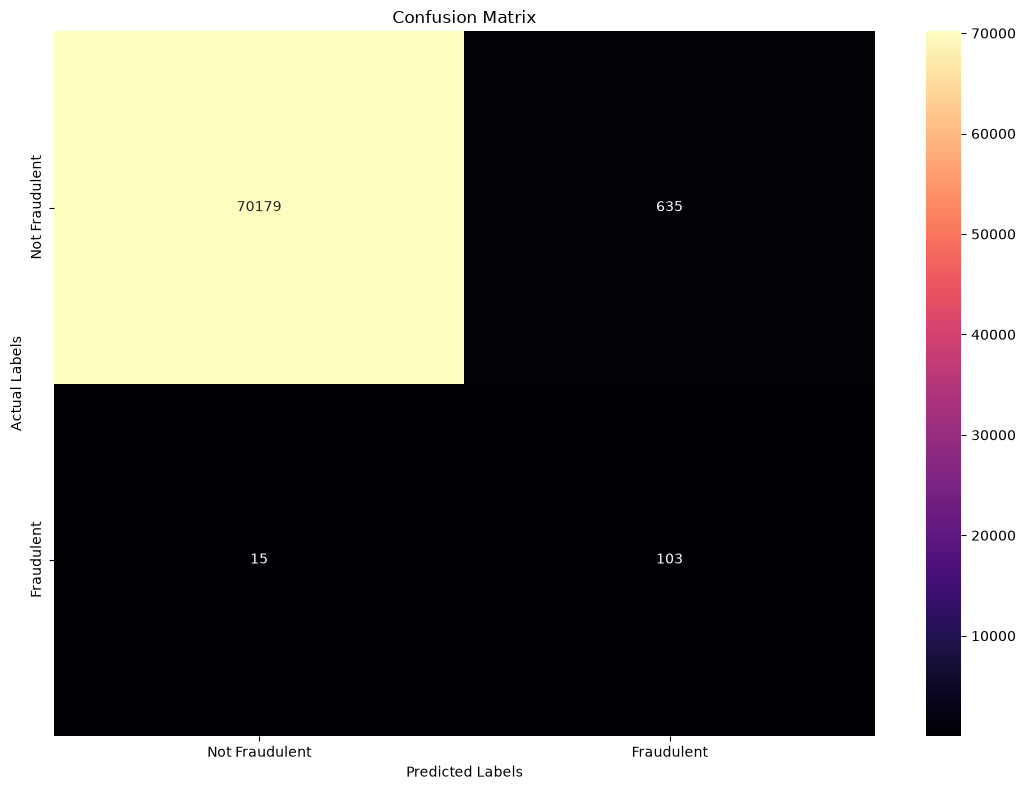

In [20]:
conf_matrix(ytest, lr_predict, ['Not Fraudulent', 'Fraudulent'])